# CardioIA — Fase 4 / Cap 1 · Parte 1
## Pré-processamento e Organização das Imagens

**Autor:** Carlos Mário Vieira de Melo Filho — RM563769  
**Dataset:** Chest X-ray Pneumonia (Kermany et al., 2018) — classes `NORMAL` / `PNEUMONIA`.

Este notebook documenta o pipeline de preparação das imagens médicas:
redimensionamento, normalização, conversão de formato (RGB) e a separação em
conjuntos de **treino / validação / teste**. Todo o pré-processamento vive em
`src/preprocessing.py` (fonte única, reutilizada também pelo app Flask), de modo
que treino e inferência usem exatamente a mesma transformação.

> Pré-requisito: rode `make dataset` (ou `python scripts/download_dataset.py`)
> para baixar e gerar o subset balanceado em `data/chest_xray_subset/`.

In [1]:
import sys
from pathlib import Path

# Permite importar o pacote src/ a partir da pasta notebooks/.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from src import config, preprocessing

print('TensorFlow:', tf.__version__)
print('Tamanho de imagem alvo:', config.IMG_SIZE)
print('Classes:', config.CLASSES)

TensorFlow: 2.16.2
Tamanho de imagem alvo: (224, 224)
Classes: ['NORMAL', 'PNEUMONIA']


### 1. Visão geral do dataset

Contagem de imagens por split e por classe no subset preparado.

In [2]:
def contar(subset_dir):
    linhas = {}
    for split in ['train', 'val', 'test']:
        linhas[split] = {}
        for classe in config.CLASSES:
            pasta = subset_dir / split / classe
            n = len(list(pasta.glob('*'))) if pasta.exists() else 0
            linhas[split][classe] = n
    return linhas

contagem = contar(config.SUBSET_DIR)
for split, classes in contagem.items():
    print(split, classes, 'total =', sum(classes.values()))

train {'NORMAL': 400, 'PNEUMONIA': 400} total = 800
val {'NORMAL': 100, 'PNEUMONIA': 100} total = 200
test {'NORMAL': 100, 'PNEUMONIA': 100} total = 200


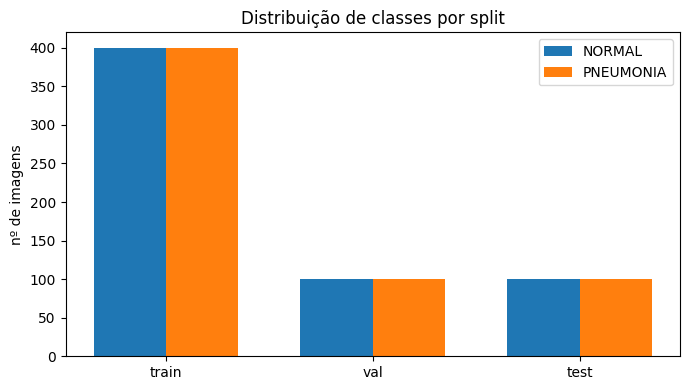

In [3]:
# Distribuição de classes por split (salva figura para o relatório).
splits = list(contagem.keys())
x = np.arange(len(splits))
largura = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
for i, classe in enumerate(config.CLASSES):
    valores = [contagem[s][classe] for s in splits]
    ax.bar(x + (i - 0.5) * largura, valores, largura, label=classe)
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel('nº de imagens'); ax.set_title('Distribuição de classes por split')
ax.legend()
config.DOCS_DIR.mkdir(exist_ok=True)
fig.tight_layout(); fig.savefig(config.DOCS_DIR / 'parte1_distribuicao_classes.png', dpi=120)
plt.show()

### 2. Amostras de imagens

Inspeção visual de exemplos de cada classe (tamanhos originais variam — por isso
o redimensionamento é necessário).

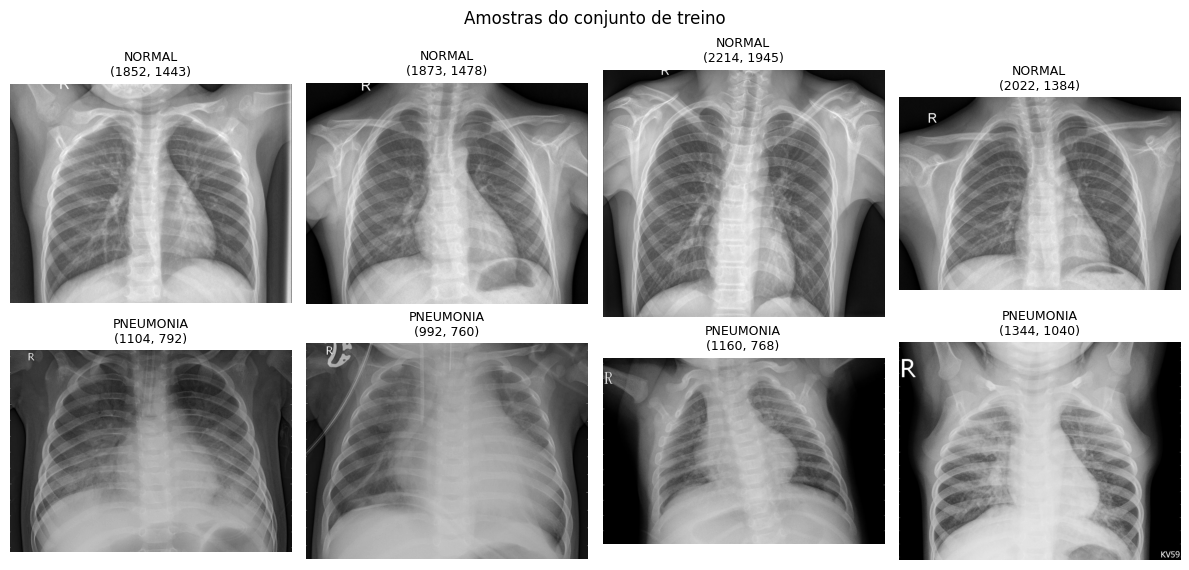

In [4]:
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for linha, classe in enumerate(config.CLASSES):
    pasta = config.SUBSET_DIR / 'train' / classe
    amostras = sorted(pasta.glob('*'))[:4]
    for col, caminho in enumerate(amostras):
        img = Image.open(caminho)
        axes[linha, col].imshow(img, cmap='gray')
        axes[linha, col].set_title(f'{classe}\n{img.size}', fontsize=9)
        axes[linha, col].axis('off')
fig.suptitle('Amostras do conjunto de treino')
fig.tight_layout(); fig.savefig(config.DOCS_DIR / 'parte1_amostras.png', dpi=120)
plt.show()

### 3. Pipeline de pré-processamento

Etapas aplicadas por `preprocessing.make_datasets()`:

1. **Leitura** das imagens das pastas `train/val/test` (rótulo inferido da pasta).
2. **Conversão para RGB** — radiografias são tons de cinza; replicamos para 3 canais
   porque o VGG16 (Parte 2) espera entrada RGB.
3. **Redimensionamento** para `224×224` (entrada padrão do VGG16).
4. **Agrupamento em batches** e `prefetch` para eficiência.
5. **Normalização** (escala [0,1]) — feita *dentro do modelo* na Parte 2, para
   evitar divergência entre treino e inferência.

Os rótulos saem em `label_mode='binary'` (0 = NORMAL, 1 = PNEUMONIA).

In [5]:
train_ds, val_ds, test_ds = preprocessing.make_datasets()

imagens, rotulos = next(iter(train_ds))
print('Shape do batch de imagens:', imagens.shape)
print('Shape dos rótulos:', rotulos.shape)
print('Faixa de valores dos pixels: [%.1f, %.1f]' % (float(imagens.numpy().min()), float(imagens.numpy().max())))
print('Exemplo de rótulos:', rotulos.numpy()[:8].ravel())

Found 800 files belonging to 2 classes.


Found 200 files belonging to 2 classes.


Found 200 files belonging to 2 classes.


Shape do batch de imagens: (32, 224, 224, 3)
Shape dos rótulos: (32, 1)
Faixa de valores dos pixels: [0.0, 255.0]
Exemplo de rótulos: [0. 0. 0. 1. 1. 1. 1. 1.]


### 4. Data augmentation

Aumentos conservadores (flip horizontal, pequena rotação e zoom) ampliam a
variabilidade do treino sem distorcer a orientação clínica. As camadas só ficam
ativas durante o treino.

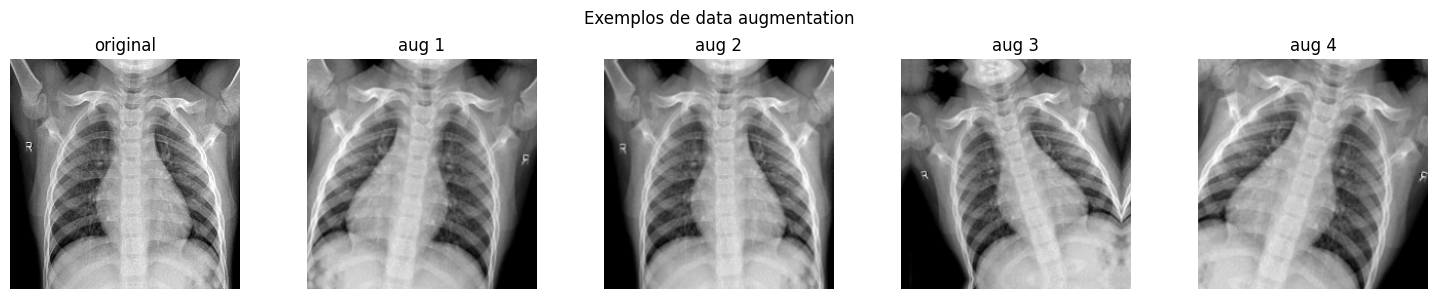

In [6]:
aug = preprocessing.build_augmentation()
exemplo = imagens[0:1]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(exemplo[0].numpy().astype('uint8')); axes[0].set_title('original'); axes[0].axis('off')
for i in range(1, 5):
    aumentada = aug(exemplo, training=True)
    axes[i].imshow(aumentada[0].numpy().astype('uint8')); axes[i].set_title(f'aug {i}'); axes[i].axis('off')
fig.suptitle('Exemplos de data augmentation')
fig.tight_layout(); fig.savefig(config.DOCS_DIR / 'parte1_augmentation.png', dpi=120)
plt.show()

### Conclusão da Parte 1

O pipeline entrega três datasets `tf.data` (treino/validação/teste) com imagens
`224×224×3` em RGB, rótulos binários e batches eficientes. As justificativas das
escolhas estão em `docs/RELATORIO_PARTE1.md`. A **Parte 2** consome esses datasets
para treinar e avaliar as CNNs.